In [ ]:
!pip install fairlearn shap scikit-learn pandas numpy google-cloud-storage matplotlib seaborn




**1. Load and Prepare the Data**





In [2]:
import pandas as pd
import numpy as np
from google.cloud import storage
import io

# Load data from GCS
from google.cloud import storage
client = storage.Client()
bucket = client.bucket('ml_ops_wk1_826')
blob = bucket.blob('v1/data.csv')
data = blob.download_as_text()

# Read into DataFrame
df = pd.read_csv(io.StringIO(data))

# Add random 'location' attribute (0 or 1)
np.random.seed(42)  # For reproducibility
df['location'] = np.random.randint(0, 2, size=len(df))

print(df.head())
print(f"\nLocation distribution:\n{df['location'].value_counts()}")

   sepal_length  sepal_width  petal_length  petal_width species  location
0           5.8          4.0           1.2          0.2  setosa         0
1           5.7          4.4           1.5          0.4  setosa         1
2           5.4          3.9           1.3          0.4  setosa         0
3           5.1          3.5           1.4          0.3  setosa         0
4           5.7          3.8           1.7          0.3  setosa         0

Location distribution:
location
1    56
0    45
Name: count, dtype: int64


**2. Prepare Features and Target**

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode target variable
le = LabelEncoder()
df['species_encoded'] = le.fit_transform(df['species'])

# Features and target
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'location']]
y = df['species_encoded']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Separate sensitive attribute
sensitive_features_train = X_train['location']
sensitive_features_test = X_test['location']

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 70
Test set size: 31


**3. Train Random Forest Classifier**

In [5]:
from sklearn.ensemble import RandomForestClassifier

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Accuracy
from sklearn.metrics import accuracy_score
print(f"Training Accuracy: {accuracy_score(y_train, y_pred_train):.3f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test):.3f}")

Training Accuracy: 1.000
Test Accuracy: 0.968


**4.  Fairlearn Implementation**

In [7]:
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, false_negative_rate
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Define metrics
metrics = {
    'accuracy': accuracy_score,
    'precision': lambda y_true, y_pred: precision_score(y_true, y_pred, average='weighted'),
    'recall': lambda y_true, y_pred: recall_score(y_true, y_pred, average='weighted'),
    'selection_rate': selection_rate
}

# Create MetricFrame for test set
metric_frame = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred_test,
    sensitive_features=sensitive_features_test
)

print("Overall Metrics:")
print(metric_frame.overall)
print("\nMetrics by Location:")
print(metric_frame.by_group)
print("\nDifference between groups:")
print(metric_frame.difference())

Overall Metrics:
accuracy          0.967742
precision         0.970430
recall            0.967742
selection_rate    0.258065
dtype: float64

Metrics by Location:
          accuracy  precision    recall  selection_rate
location                                               
0         0.928571   0.942857  0.928571        0.428571
1         1.000000   1.000000  1.000000        0.117647

Difference between groups:
accuracy          0.071429
precision         0.057143
recall            0.071429
selection_rate    0.310924
dtype: float64


**5. Fairness Visualization**

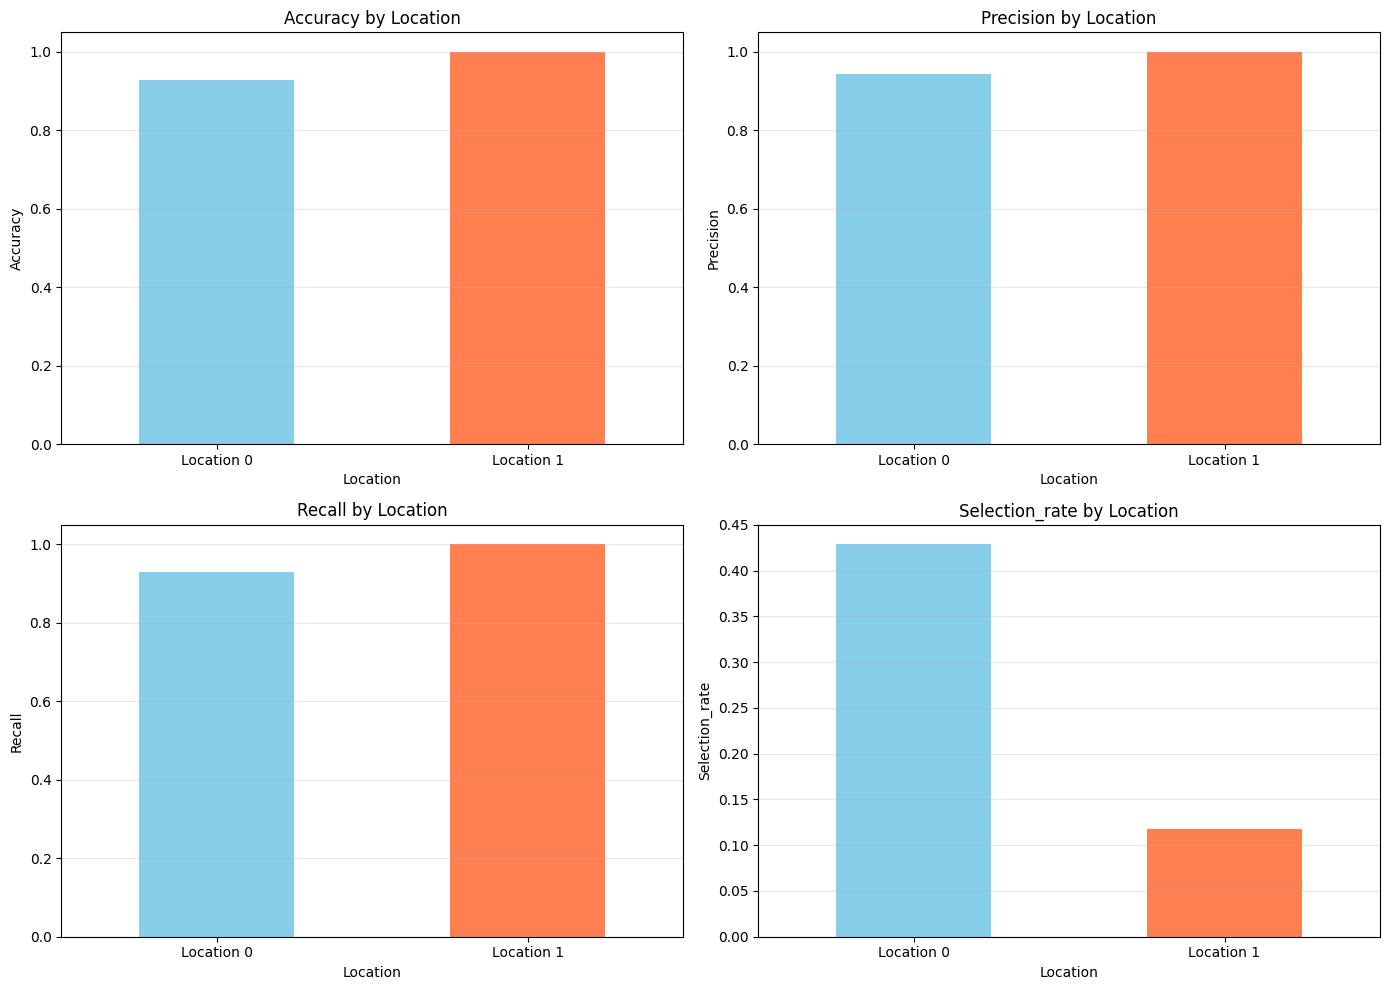

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize fairness metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (metric_name, ax) in enumerate(zip(['accuracy', 'precision', 'recall', 'selection_rate'], axes.flatten())):
    metric_by_group = metric_frame.by_group[metric_name]
    metric_by_group.plot(kind='bar', ax=ax, color=['skyblue', 'coral'])
    ax.set_title(f'{metric_name.capitalize()} by Location', fontsize=12)
    ax.set_xlabel('Location')
    ax.set_ylabel(metric_name.capitalize())
    ax.set_xticklabels(['Location 0', 'Location 1'], rotation=0)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fairness_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

**6. SHAP Explainability for Virginica Class**